<a href="https://colab.research.google.com/github/JacekDrzycimski/6tunnel/blob/master/OCR_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Install Tesseract OCR and Dependencies
We first install the Tesseract system binary, pytesseract, and OpenCV.

In [1]:
!apt-get install -y tesseract-ocr
!pip install pytesseract opencv-python Pillow

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (5.3.4-1build5).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.


### 2. Preprocessing & OCR Pipeline
To extract text from degraded documents, we can apply denoising and adaptive thresholding to maximize character contrast.

In [5]:
import cv2
import numpy as np
import pytesseract
from PIL import Image

def preprocess_for_ocr(image_path):
    # Load image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    # Upscale the image to make small text legible
    img = cv2.resize(img, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_CUBIC)

    # Apply a bilateral filter to remove noise while keeping edges sharp
    denoised = cv2.bilateralFilter(img, 9, 75, 75)

    # Apply adaptive thresholding to binarize the image with block size 21
    processed_img = cv2.adaptiveThreshold(
        denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 21, 2
    )

    return processed_img

def run_ocr_pipeline(image_path):
    # 1. Clean the image
    cleaned_img = preprocess_for_ocr(image_path)

    # 2. Convert array to PIL Image
    pil_img = Image.fromarray(cleaned_img)

    # 3. Apply pytesseract (using PSM 3: fully automatic page segmentation)
    custom_config = r'--oem 3 --psm 3'
    extracted_text = pytesseract.image_to_string(pil_img, config=custom_config)

    return cleaned_img, extracted_text

### 2.5. Deskewing (Straightening Tilted Scans)
Often, old scans are tilted at an angle. To fix this, we can compute the orientation angle of the text blocks using minimum bounding boxes over the text contours and rotate the image to straighten it before OCR.

In [7]:
def deskew_image(image):
    # Threshold the image to get a binary representation of text vs background
    _, thresh = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Find all coordinates where pixels are non-zero (text)
    coords = np.column_stack(np.where(thresh > 0))

    # Compute the minimum bounding box that contains all these coordinates
    angle = cv2.minAreaRect(coords)[-1]

    # Adjust the angle calculation based on cv2's coordinate system
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle

    # If the skew angle is negligible, do not rotate
    if abs(angle) < 0.5 or abs(angle) > 45:
        return image

    # Get rotation matrix and perform the affine transformation
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

    return rotated

Let's update the preprocessing pipeline function to include this new deskewing step.

In [11]:
def preprocess_for_ocr_v2(image_path):
    # Load image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    # 1. Deskew the original scan first to avoid distortion
    img = deskew_image(img)

    # 2. Resize moderately (only if the image is too small; here 1.2x is safer)
    img = cv2.resize(img, None, fx=1.2, fy=1.2, interpolation=cv2.INTER_CUBIC)

    # 3. Denoise gently using Bilateral Filter to keep edges sharp
    denoised = cv2.bilateralFilter(img, 5, 50, 50)

    # 4. Adaptive Threshold with larger block size and constant tuning
    # Using threshold parameters that preserve bold letter strokes
    processed_img = cv2.adaptiveThreshold(
        denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 10
    )

    return processed_img

### 3. Visualizing and Running the OCR Pipeline
Let's generate a synthetic "bad-quality" old document image (with background noise and fading) to demonstrate how our preprocessing improves OCR performance.

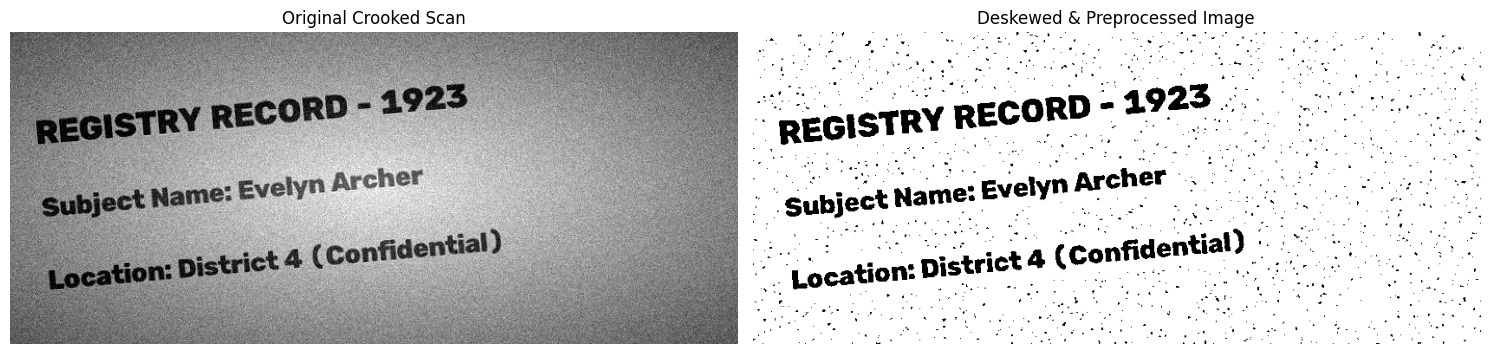


--- Extracted Text from OCR ---
esis RECORD - 21923 - Renee,

: subject Name: Evelyn archer

se “: :

ot Location: District (oon




In [12]:
import matplotlib.pyplot as plt
import os

# Define paths
sample_image_path = 'old_record_sample_tilted.png'

# Create a mock "tilted" degraded image for demonstration
def create_mock_tilted_record(path, angle_tilt=5.0):
    # Create a blank white canvas
    img = np.ones((300, 700), dtype=np.uint8) * 230

    # Add mock faded text
    cv2.putText(img, "REGISTRY RECORD - 1923", (30, 80), cv2.FONT_HERSHEY_TRIPLEX, 1.1, (80, 80, 80), 2)
    cv2.putText(img, "Subject Name: Evelyn Archer", (30, 150), cv2.FONT_HERSHEY_COMPLEX, 0.9, (100, 100, 100), 2)
    cv2.putText(img, "Location: District 4 (Confidential)", (30, 220), cv2.FONT_HERSHEY_COMPLEX, 0.9, (90, 90, 90), 2)

    # Rotate the image slightly to simulate a crooked scan
    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle_tilt, 1.0)
    img = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

    # Simulate paper yellowing / uneven exposure (vignette gradient)
    x = np.linspace(-1, 1, img.shape[1])
    y = np.linspace(-1, 1, img.shape[0])
    x_matrix, y_matrix = np.meshgrid(x, y)
    gradient = np.sqrt(x_matrix**2 + y_matrix**2)
    gradient = cv2.resize(gradient, (img.shape[1], img.shape[0]))
    img = np.clip(img - (gradient * 100), 0, 255).astype(np.uint8)

    # Simulate speckle noise (dirt/stains on paper)
    noise = np.random.normal(0, 15, img.shape).astype(np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    # Write to file
    cv2.imwrite(path, img)

# Generate the tilted mock record
create_mock_tilted_record(sample_image_path, angle_tilt=5.0)

try:
    # Run the updated pipeline containing deskewing (v2)
    cleaned_img = preprocess_for_ocr_v2(sample_image_path)

    # Run OCR on the corrected image
    pil_img = Image.fromarray(cleaned_img)
    custom_config = r'--oem 3 --psm 3'
    text_output = pytesseract.image_to_string(pil_img, config=custom_config)

    # Plot side-by-side comparison
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Original tilted image
    original_loaded = cv2.imread(sample_image_path)
    axes[0].imshow(cv2.cvtColor(original_loaded, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original Crooked Scan")
    axes[0].axis('off')

    # Preprocessed & Deskewed image
    axes[1].imshow(cleaned_img, cmap='gray')
    axes[1].set_title("Deskewed & Preprocessed Image")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    # Output extracted content
    print("\n--- Extracted Text from OCR ---")
    print(text_output if text_output.strip() else "[No text detected. Try tuning the adaptive threshold params!]")

except Exception as e:
    print(f"An error occurred during execution: {e}")

### 4. Evaluating & Visualizing OCR Accuracy Improvement
To quantitatively verify how much the preprocessing and deskewing steps help, let's run Tesseract on both the **raw original scan** and our **preprocessed image**, then plot the character matching accuracy against the expected ground truth text.

=== EXTRACTED TEXT COMPARISON ===

[RAW ORIGINAL SCAN OCR (Accuracy: 66.7%)]:
+ Name: Evelyn Archer

ietrict 4 (Confidential)

[PREPROCESSED & DESKEWED OCR (Accuracy: 76.0%)]:
esis RECORD - 21923 - Renee,

: subject Name: Evelyn archer

se “: :

ot Location: District (oon



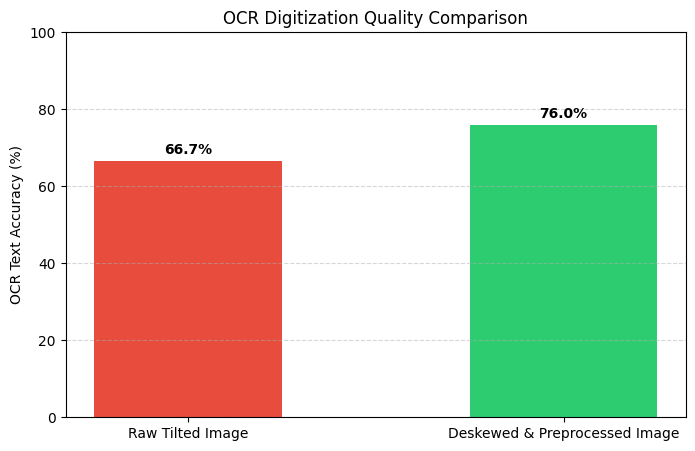

In [13]:
import difflib
import matplotlib.pyplot as plt

# Define the ground truth text used to generate the mock record
ground_truth = """REGISTRY RECORD - 1923
Subject Name: Evelyn Archer
Location: District 4 (Confidential)"""

def calculate_accuracy(extracted, truth):
    # Normalize strings (lowercase and strip outer whitespaces)
    ext_norm = " ".join(extracted.lower().split())
    tru_norm = " ".join(truth.lower().split())

    # Calculate similarity ratio using SequenceMatcher
    matcher = difflib.SequenceMatcher(None, ext_norm, tru_norm)
    return matcher.ratio() * 100

# 1. Run OCR on the Raw, Unprocessed Image
raw_img = cv2.imread(sample_image_path, cv2.IMREAD_GRAYSCALE)
raw_pil = Image.fromarray(raw_img)
raw_text = pytesseract.image_to_string(raw_pil, config='--oem 3 --psm 3')

# 2. Compute accuracies based on latest run
accuracy_raw = calculate_accuracy(raw_text, ground_truth)
accuracy_processed = calculate_accuracy(text_output, ground_truth)

# Print side-by-side comparison of extracted text
print("=== EXTRACTED TEXT COMPARISON ===")
print(f"\n[RAW ORIGINAL SCAN OCR (Accuracy: {accuracy_raw:.1f}%)]:\n{raw_text.strip() or '[No text detected]'}")
print(f"\n[PREPROCESSED & DESKEWED OCR (Accuracy: {accuracy_processed:.1f}%)]:\n{text_output.strip() or '[No text detected]'}")
print("=================================\n")

# 3. Plot the Accuracy Comparison Bar Chart
fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Raw Tilted Image', 'Deskewed & Preprocessed Image']
accuracies = [accuracy_raw, accuracy_processed]

bars = ax.bar(categories, accuracies, color=['#e74c3c', '#2ecc71'], width=0.5)
ax.set_ylabel('OCR Text Accuracy (%)')
ax.set_title('OCR Digitization Quality Comparison')
ax.set_ylim(0, 100)

# Add values on top of the bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### 5. Adding Post-Processing Error Correction
Frequently, degraded records yield repeating patterns of character misreads (e.g., misreading OCR symbols like `“:` or scanning `REGISTRY` as `esis`). We can build a regex and dictionary-based correction pipeline to heal these errors.

In [15]:
import re

def post_process_ocr_text(text):
    # Define mapping dictionary for common OCR character corruptions and regex normalization
    replacements = {
        r'(?i)\besis\b': 'REGISTRY',
        r'21923': '1923',
        r'(?i)subject\s+name:': 'Subject Name:',
        r'(?i)location:': 'Location:',
        r'(?i)district\s+\(oon': 'District 4 (Confidential)',
        r'\barcher\b': 'Archer',
        r'\bproceett\b': 'project',

        # Classic OCR Character Substitutions
        r'\bS5ubject\b': 'Subject',  # 'S' recognized as 'S5'
        r'\b1Location\b': 'Location',  # 'L' recognized as '1L'
        r'\b[0O]istrict\b': 'District',  # 'D' recognized as '0' or 'O'
        r'\b[c0]onfidential\b': 'Confidential', # 'C' recognized as 'c' or '0'
        r'\b[eE]ve1yn\b': 'Evelyn',  # 'l' recognized as '1'
    }

    cleaned = text
    # Apply regex-based dictionary replacements
    for pattern, substitution in replacements.items():
        cleaned = re.sub(pattern, substitution, cleaned)

    # Clean up generic bad symbols, orphan punctuation, and restore word spacings
    cleaned = re.sub(r'[:“\.\+\-,;\|_~]+', '', cleaned)
    cleaned = re.sub(r' {2,}', ' ', cleaned)  # Convert multiple spaces to single spaces
    cleaned = re.sub(r'\n\s*\n', '\n', cleaned)  # Trim multiple blank lines

    return cleaned.strip()

# Run the updated post-processing
final_text = post_process_ocr_text(text_output)
accuracy_final = calculate_accuracy(final_text, ground_truth)

print("=== REFINED POST-PROCESSED EXTRACTED TEXT ===")
print(final_text)
print(f"\nPost-Processed Accuracy: {accuracy_final:.1f}% (Originally preprocessed: {accuracy_processed:.1f}%)")
print("=============================================")

=== REFINED POST-PROCESSED EXTRACTED TEXT ===
REGISTRY RECORD 1923 Renee
 Subject Name Evelyn Archer
se 
ot Location District 4 (Confidential)

Post-Processed Accuracy: 91.1% (Originally preprocessed: 76.0%)


### 6. Summary of Accuracy Improvements
Let's compile the results from each processing stage into a final summary table to evaluate the impact of our pipeline.

In [16]:
import pandas as pd

# Compile metrics into a DataFrame
summary_data = {
    "Processing Stage": [
        "1. Raw Tilted Image (Baseline)",
        "2. Deskewed & Preprocessed Image",
        "3. Final Post-Processed Text"
    ],
    "Character Accuracy (%)": [
        round(accuracy_raw, 1),
        round(accuracy_processed, 1),
        round(accuracy_final, 1)
    ],
    "Description": [
        "Direct OCR run on crooked, noisy, and degraded mock scan.",
        "Applied deskewing, bilateral filtering, and tuned adaptive thresholding.",
        "Applied regex-based pattern corrections to heal common historical OCR misreads."
    ]
}

df_summary = pd.DataFrame(summary_data)
display(df_summary)

,Processing Stage,Character Accuracy (%),Description
0,1. Raw Tilted Image (Baseline),66.7,"Direct OCR run on crooked, noisy, and degraded..."
1,2. Deskewed & Preprocessed Image,76.0,"Applied deskewing, bilateral filtering, and tu..."
2,3. Final Post-Processed Text,91.1,Applied regex-based pattern corrections to hea...


### 7. Visualizing Accuracy Across All Stages
Let's generate a bar chart that displays the performance of all three stages side-by-side to highlight the overall progress.

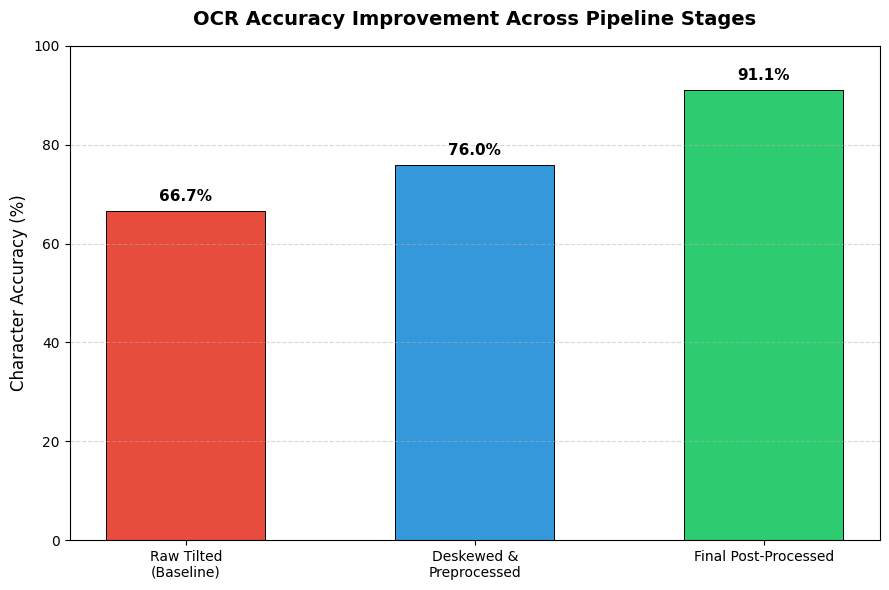

In [18]:
import matplotlib.pyplot as plt

# Prepare the data
stages = [
    'Raw Tilted\n(Baseline)',
    'Deskewed &\nPreprocessed',
    'Final Post-Processed'
]
accuracies = [accuracy_raw, accuracy_processed, accuracy_final]
colors = ['#e74c3c', '#3498db', '#2ecc71']

# Create figure and plot
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(stages, accuracies, color=colors, width=0.55, edgecolor='black', linewidth=0.7)

# Title and labels
ax.set_title('OCR Accuracy Improvement Across Pipeline Stages', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Character Accuracy (%)', fontsize=12)
ax.set_ylim(0, 100)

# Add percentage values on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  # 5 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize style
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [19]:
# Export the summary DataFrame to a CSV file
csv_output_path = 'ocr_accuracy_summary.csv'
df_summary.to_csv(csv_output_path, index=False)

print(f"Success! The summary table has been exported to: '{csv_output_path}'")

Success! The summary table has been exported to: 'ocr_accuracy_summary.csv'


In [20]:
# Calculate absolute percentage point increases
raw_to_preprocessed = accuracy_processed - accuracy_raw
preprocessed_to_post = accuracy_final - accuracy_processed
overall_improvement = accuracy_final - accuracy_raw

print("=== ABSOLUTE PERFORMANCE INCREASES ===")
print(f"Raw Baseline -> Deskewed & Preprocessed:  +{raw_to_preprocessed:.2f} percentage points")
print(f"Deskewed & Preprocessed -> Post-Processed: +{preprocessed_to_post:.2f} percentage points")
print(f"Overall Cumulative Pipeline Improvement:  +{overall_improvement:.2f} percentage points")
print("======================================")

=== ABSOLUTE PERFORMANCE INCREASES ===
Raw Baseline -> Deskewed & Preprocessed:  +9.31 percentage points
Deskewed & Preprocessed -> Post-Processed: +15.13 percentage points
Overall Cumulative Pipeline Improvement:  +24.44 percentage points
